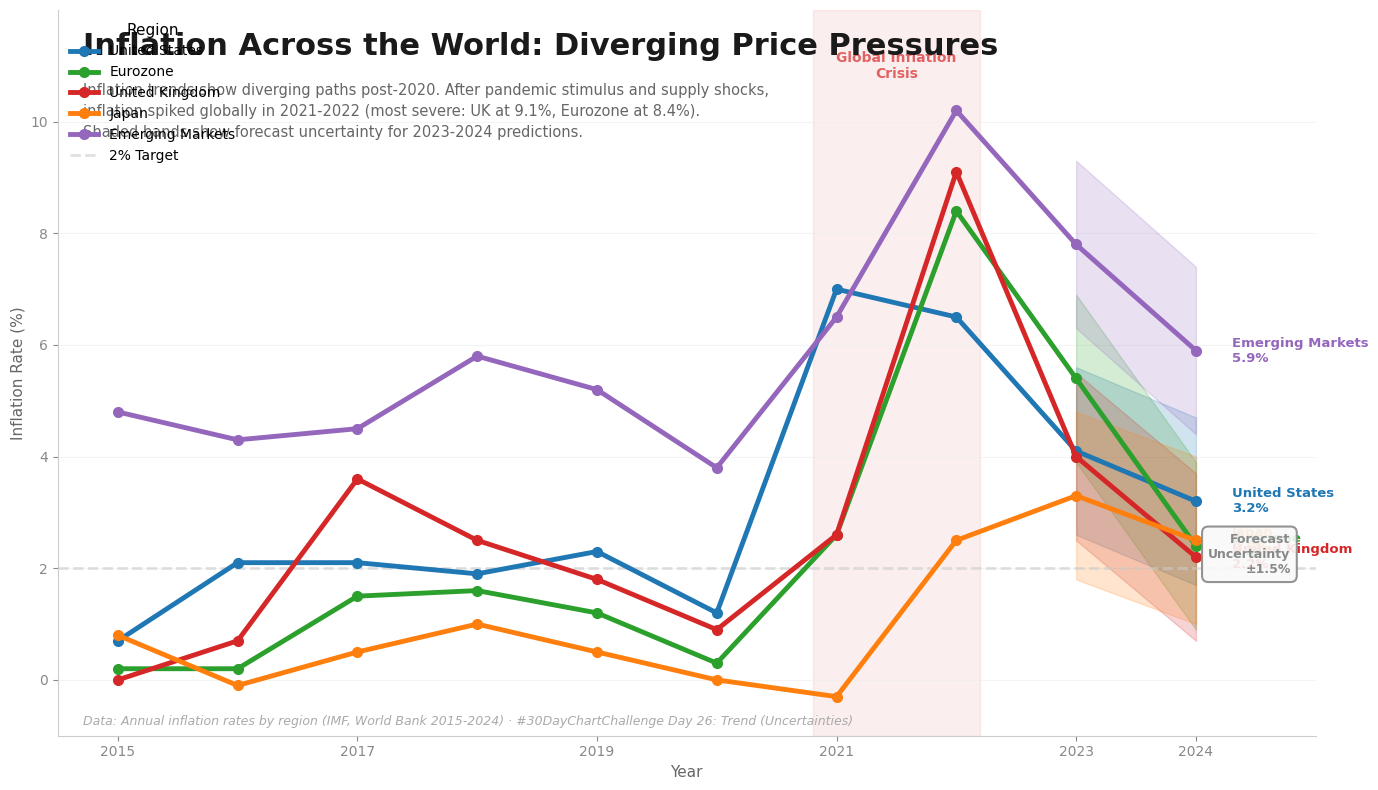

In [1]:
"""
#30DayChartChallenge — Day 26: Trend (Uncertainties)
"Inflation Across the World: Diverging Price Pressures" — trend lines with uncertainty bands
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Inflation rate trends by region with forecast uncertainty (2015-2024)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Annual inflation rates by region (%)
# ---------------------------------------------------------------------------
data = {
    "Year": [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    "United_States": [0.7, 2.1, 2.1, 1.9, 2.3, 1.2, 7.0, 6.5, 4.1, 3.2],
    "Eurozone": [0.2, 0.2, 1.5, 1.6, 1.2, 0.3, 2.6, 8.4, 5.4, 2.4],
    "United_Kingdom": [0.0, 0.7, 3.6, 2.5, 1.8, 0.9, 2.6, 9.1, 4.0, 2.2],
    "Japan": [0.8, -0.1, 0.5, 1.0, 0.5, -0.0, -0.3, 2.5, 3.3, 2.5],
    "Emerging_Markets": [4.8, 4.3, 4.5, 5.8, 5.2, 3.8, 6.5, 10.2, 7.8, 5.9]
}

df = pd.DataFrame(data)

# Add uncertainty bands (±1.5% after 2023, representing forecast uncertainty)
uncertainty = 1.5

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Color palette
colors = {
    "United_States": "#1f77b4",
    "Eurozone": "#2ca02c",
    "United_Kingdom": "#d62728",
    "Japan": "#ff7f0e",
    "Emerging_Markets": "#9467bd"
}

region_labels = {
    "United_States": "United States",
    "Eurozone": "Eurozone",
    "United_Kingdom": "United Kingdom",
    "Japan": "Japan",
    "Emerging_Markets": "Emerging Markets"
}

# Plot trend lines with uncertainty bands
for region in ["United_States", "Eurozone", "United_Kingdom", "Japan", "Emerging_Markets"]:
    # Main line
    ax.plot(df["Year"], df[region], color=colors[region], linewidth=3.5, 
            marker="o", markersize=7, label=region_labels[region], zorder=3)
    
    # Uncertainty band (shaded) for forecast period (2023-2024)
    forecast_mask = df["Year"] >= 2023
    forecast_years = df.loc[forecast_mask, "Year"]
    forecast_vals = df.loc[forecast_mask, region]
    
    ax.fill_between(forecast_years, 
                    forecast_vals - uncertainty, 
                    forecast_vals + uncertainty,
                    color=colors[region], alpha=0.2, zorder=1)

# Add trend reference: 2% inflation target
ax.axhline(y=2.0, color="#cccccc", linewidth=2, linestyle="--", alpha=0.6, zorder=2, label="2% Target")

# Highlight inflation shock (2021-2022)
ax.axvspan(2020.8, 2022.2, alpha=0.08, color="#d62728", zorder=0)
ax.text(2021.5, 11, "Global Inflation\nCrisis", fontsize=10, fontweight="bold", 
        color="#d62728", ha="center", va="center", alpha=0.7)

# Direct labels at end of lines
for region in ["United_States", "Eurozone", "United_Kingdom", "Japan", "Emerging_Markets"]:
    last_val = df[region].iloc[-1]
    ax.text(2024.3, last_val, f"{region_labels[region]}\n{last_val:.1f}%",
            fontsize=9.5, fontweight="600", color=colors[region], va="center")

# Minimal styling
ax.set_xlim(2014.5, 2025)
ax.set_ylim(-1, 12)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, axis="y", zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("Year", fontsize=11, color="#666666", fontweight="500")
ax.set_ylabel("Inflation Rate (%)", fontsize=11, color="#666666", fontweight="500")
ax.set_xticks([2015, 2017, 2019, 2021, 2023, 2024])
ax.set_yticks([0, 2, 4, 6, 8, 10])
ax.tick_params(colors="#888888", labelsize=10)

# Legend
ax.legend(loc="upper left", fontsize=10, frameon=False, title="Region", title_fontsize=11)

# Title & subtitle
ax.text(0.02, 0.97, "Inflation Across the World: Diverging Price Pressures",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "Inflation trends show diverging paths post-2020. After pandemic stimulus and supply shocks,\n"
        "inflation spiked globally in 2021-2022 (most severe: UK at 9.1%, Eurozone at 8.4%).\n"
        "Shaded bands show forecast uncertainty for 2023-2024 predictions.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Uncertainty note
ax.text(0.98, 0.25, "Forecast\nUncertainty\n±1.5%",
        fontsize=9, color="#888888", fontweight="bold", transform=ax.transAxes, 
        ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="#888888", linewidth=1.5, alpha=0.9))

# Source
ax.text(0.02, 0.01,
        "Data: Annual inflation rates by region (IMF, World Bank 2015-2024) · #30DayChartChallenge Day 26: Trend (Uncertainties)",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day26_trend.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()